In [8]:
import nibabel as nib
import numpy as np

# Load ground truth & reconstruction
gt_img =  nib.load("/projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/data/nnUNet_preprocessed/Dataset001_nnunet/gt_segmentations/case_022.nii.gz")
recon_img = nib.load("/projectnb/ec500kb/projects/Project_4/Graph_Creations/Everything_For_Docker/output2/pred_case_022_0000.nii.gz")

gt = gt_img.get_fdata().astype(int)
recon = recon_img.get_fdata().astype(int)

classes = {1: "artery", 2: "vein"}

# Build confusion matrix (multi-class)
max_class = max(gt.max(), recon.max())
cm = np.zeros((max_class+1, max_class+1), dtype=int)
for c in range(max_class+1):
    for r in range(max_class+1):
        cm[c, r] = np.sum((gt == c) & (recon == r))

# For each class, compute TP, FP, FN, TN, and FPR/FNR
results = {}
total_voxels = gt.size

for cls, name in classes.items():
    TP = cm[cls, cls]
    FP = cm[:, cls].sum() - TP         # predicted cls but GT is not cls
    FN = cm[cls, :].sum() - TP         # GT is cls but predicted not cls
    TN = total_voxels - (TP + FP + FN)

    # Rates
    FPR = FP / (FP + TN + 1e-8)   # how often non-cls voxels wrongly predicted as cls 
    FNR = FN / (TP + FN + 1e-8)   # how often cls voxels missed

    results[name] = {
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TN": TN,
        "FPR": FPR,
        "FNR": FNR
    }

for name, vals in results.items():
    print(f"\nClass = {name}")
    print(" TP:", vals["TP"])
    print(" FP:", vals["FP"])
    print(" FN:", vals["FN"])
    print(" TN:", vals["TN"])
    print(f" False Positive Rate (FPR): {vals['FPR']:.4f}")
    print(f" False Negative Rate (FNR): {vals['FNR']:.4f}")



Class = artery
 TP: 520046
 FP: 253824
 FN: 198430
 TN: 86059508
 False Positive Rate (FPR): 0.0029
 False Negative Rate (FNR): 0.2762

Class = vein
 TP: 490651
 FP: 284288
 FN: 233590
 TN: 86023279
 False Positive Rate (FPR): 0.0033
 False Negative Rate (FNR): 0.3225


,scope,Dice,IoU,FP,FN,TP,TN,n_pred,n_ref,FP_rate,FN_rate
0,foreground_mean,0.885616,0.798010,35760.029412,65096.529412,366156.029412,8.233965e+07,401916.058824,431252.558824,0.082921,0.150948
1,mean_artery,0.889559,0.804042,30466.352941,57923.058824,337961.117647,8.238031e+07,368427.470588,395884.176471,0.076958,0.146313
2,mean_vein,0.881672,0.791979,41053.705882,72270.000000,394350.941176,8.229899e+07,435404.647059,466620.941176,0.087981,0.154879


,case,FP_artery,FN_artery,n_ref_artery,FP_rate_artery,FN_rate_artery,FP_vein,FN_vein,n_ref_vein,FP_rate_vein,FN_rate_vein,FP_total,FN_total,n_ref_total,FP_rate_total,FN_rate_total
0,case_244,23671,191077,531274,0.044555,0.359658,19126,267191,718667,0.026613,0.371787,42797,458268,1249941,0.034239,0.366632
1,case_218,23934,146451,539085,0.044397,0.271666,26544,201333,770722,0.034440,0.261226,50478,347784,1309807,0.038539,0.265523
2,case_242,47010,106742,575250,0.081721,0.185558,70483,159440,681307,0.103453,0.234021,117493,266182,1256557,0.093504,0.211834
3,case_233,53484,87358,461950,0.115779,0.189107,96660,80102,517777,0.186683,0.154704,150144,167460,979727,0.153251,0.170925
4,case_214,52421,64157,419121,0.125074,0.153075,66819,102916,421374,0.158574,0.244239,119240,167073,840495,0.141869,0.198779
5,case_128,5618,75232,449167,0.012508,0.167492,19217,66831,452797,0.042441,0.147596,24835,142063,901964,0.027534,0.157504
6,case_145,8208,72075,351296,0.023365,0.205169,13661,61751,411875,0.033168,0.149927,21869,133826,763171,0.028655,0.175355
7,case_099,15196,36971,340853,0.044582,0.108466,16596,35641,347382,0.047774,0.102599,31792,72612,688235,0.046194,0.105505
8,case_129,12875,26712,237288,0.054259,0.112572,11080,42708,315727,0.035094,0.135269,23955,69420,553015,0.043317,0.125530
9,case_052,22925,32629,418647,0.054760,0.077939,46868,34759,459614,0.101973,0.075627,69793,67388,878261,0.079467,0.076729


<Figure size 800x400 with 0 Axes>

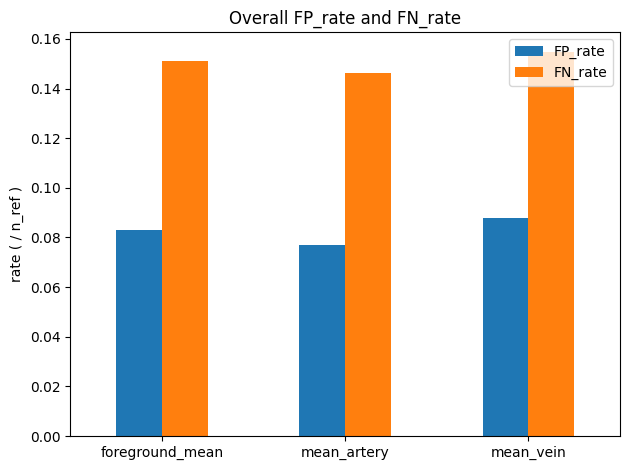

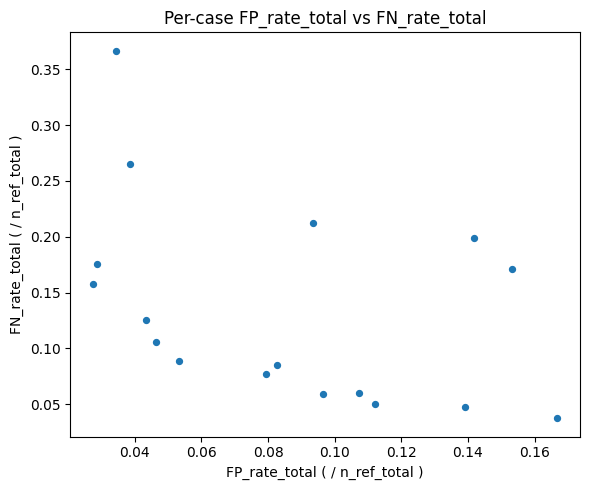

<Figure size 1000x500 with 0 Axes>

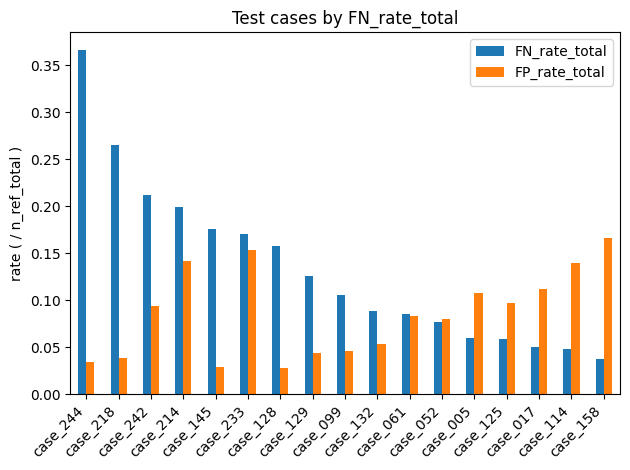

In [3]:
# nnunet baseline
import json
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

METRICS_JSON = Path("/projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/data/nnUNet_results/Dataset001_nnunet/preds/ensemble_seed1-10/metrics.json")
CLASS_NAMES = {"artery": "1", "vein": "2"}

def extract_case_id(pred_path: str) -> str:
    m = re.search(r"(case_\d+)", pred_path or "")
    if m:
        return m.group(1)
    p = Path(pred_path) if pred_path else Path("unknown")
    name = p.name
    if name.endswith(".nii.gz"):
        return name[:-7]
    return p.stem

def extract_fp_fn(metric_dict: dict):
    if not isinstance(metric_dict, dict):
        return (None, None)
    if "False_Positive_and_Negative_Score" in metric_dict:
        v = metric_dict["False_Positive_and_Negative_Score"]
        if isinstance(v, (list, tuple)) and len(v) == 2:
            return (v[0], v[1])
        if isinstance(v, dict):
            fp = v.get("FP", v.get("false_positive", v.get("fp", None)))
            fn = v.get("FN", v.get("false_negative", v.get("fn", None)))
            if fp is not None or fn is not None:
                return (fp, fn)
    return (metric_dict.get("FP", None), metric_dict.get("FN", None))

def safe_rate(num, den):
    if num is None or den is None:
        return None
    try:
        den = float(den)
        if den == 0:
            return None
        return float(num) / den
    except Exception:
        return None

with METRICS_JSON.open("r") as f:
    data = json.load(f)

per_case = data.get("metric_per_case", [])
if not per_case:
    raise ValueError(f"No 'metric_per_case' found in {METRICS_JSON}")

rows = []
for item in per_case:
    pred_file = item.get("prediction_file", "")
    case_id = extract_case_id(pred_file)
    metrics = item.get("metrics", {})
    m_art = metrics.get(CLASS_NAMES["artery"], {})
    m_vein = metrics.get(CLASS_NAMES["vein"], {})

    fp_a, fn_a = extract_fp_fn(m_art)
    fp_v, fn_v = extract_fp_fn(m_vein)

    nref_a = m_art.get("n_ref", None) if isinstance(m_art, dict) else None
    nref_v = m_vein.get("n_ref", None) if isinstance(m_vein, dict) else None

    fp_total = (fp_a + fp_v) if (fp_a is not None and fp_v is not None) else None
    fn_total = (fn_a + fn_v) if (fn_a is not None and fn_v is not None) else None
    nref_total = (nref_a + nref_v) if (nref_a is not None and nref_v is not None) else None

    rows.append({
        "case": case_id,

        "FP_artery": fp_a,
        "FN_artery": fn_a,
        "n_ref_artery": nref_a,
        "FP_rate_artery": safe_rate(fp_a, nref_a),
        "FN_rate_artery": safe_rate(fn_a, nref_a),

        "FP_vein": fp_v,
        "FN_vein": fn_v,
        "n_ref_vein": nref_v,
        "FP_rate_vein": safe_rate(fp_v, nref_v),
        "FN_rate_vein": safe_rate(fn_v, nref_v),

        "FP_total": fp_total,
        "FN_total": fn_total,
        "n_ref_total": nref_total,
        "FP_rate_total": safe_rate(fp_total, nref_total),
        "FN_rate_total": safe_rate(fn_total, nref_total),
    })

df_cases = pd.DataFrame(rows).sort_values(
    by=["FN_total", "FP_total"],
    ascending=[False, False],
    na_position="last"
).reset_index(drop=True)

fg = data.get("foreground_mean", None)
m = data.get("mean", None)
if fg is None or m is None or CLASS_NAMES["artery"] not in m or CLASS_NAMES["vein"] not in m:
    raise ValueError("Missing keys: require top-level 'foreground_mean' and 'mean' with class IDs for artery/vein.")

def pick_stats_with_rate(d: dict):
    out = {
        "Dice": d.get("Dice", None),
        "IoU": d.get("IoU", None),
        "FP": d.get("FP", None),
        "FN": d.get("FN", None),
        "TP": d.get("TP", None),
        "TN": d.get("TN", None),
        "n_pred": d.get("n_pred", None),
        "n_ref": d.get("n_ref", None),
    }
    out["FP_rate"] = safe_rate(out["FP"], out["n_ref"])
    out["FN_rate"] = safe_rate(out["FN"], out["n_ref"])
    return out

df_overall = pd.DataFrame([
    {"scope": "foreground_mean", **pick_stats_with_rate(fg)},
    {"scope": "mean_artery", **pick_stats_with_rate(m[CLASS_NAMES["artery"]])},
    {"scope": "mean_vein", **pick_stats_with_rate(m[CLASS_NAMES["vein"]])},
])

display(df_overall)
display(df_cases)

overall_plot = df_overall.set_index("scope")[["FP_rate", "FN_rate"]].astype(float)

plt.figure(figsize=(8, 4))
overall_plot.plot(kind="bar")
plt.title("Overall FP_rate and FN_rate")
plt.xlabel("")
plt.ylabel("rate ( / n_ref )")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plot_df = df_cases[["case", "FP_rate_total", "FN_rate_total"]].copy()
plot_df["FP_rate_total"] = pd.to_numeric(plot_df["FP_rate_total"], errors="coerce")
plot_df["FN_rate_total"] = pd.to_numeric(plot_df["FN_rate_total"], errors="coerce")
plot_df = plot_df.dropna(subset=["FP_rate_total", "FN_rate_total"])

plt.figure(figsize=(6, 5))
plt.scatter(plot_df["FP_rate_total"], plot_df["FN_rate_total"], s=18)
plt.title("Per-case FP_rate_total vs FN_rate_total")
plt.xlabel("FP_rate_total ( / n_ref_total )")
plt.ylabel("FN_rate_total ( / n_ref_total )")
plt.tight_layout()
plt.show()

TOPK = 20
topk = df_cases[["case", "FP_rate_total", "FN_rate_total"]].copy()
topk["FP_rate_total"] = pd.to_numeric(topk["FP_rate_total"], errors="coerce")
topk["FN_rate_total"] = pd.to_numeric(topk["FN_rate_total"], errors="coerce")
topk = topk.dropna(subset=["FP_rate_total", "FN_rate_total"]).sort_values("FN_rate_total", ascending=False).head(TOPK)

topk_plot = topk.set_index("case")[["FN_rate_total", "FP_rate_total"]]

plt.figure(figsize=(10, 5))
topk_plot.plot(kind="bar")
plt.title(f"Test cases by FN_rate_total")
plt.xlabel("")
plt.ylabel("rate ( / n_ref_total )")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


,scope,Dice,IoU,FP,FN,TP,TN,n_pred,n_ref,FP_rate,FN_rate
0,foreground_mean,0.885825,0.798272,37961.382353,62986.176471,368266.382353,8.233745e+07,406227.764706,431252.558824,0.088026,0.146054
1,mean_artery,0.888772,0.802650,33489.823529,55944.823529,339939.352941,8.237729e+07,373429.176471,395884.176471,0.084595,0.141316
2,mean_vein,0.882877,0.793894,42432.941176,70027.529412,396593.411765,8.229761e+07,439026.352941,466620.941176,0.090937,0.150074


,case,FP_artery,FN_artery,n_ref_artery,FP_rate_artery,FN_rate_artery,FP_vein,FN_vein,n_ref_vein,FP_rate_vein,FN_rate_vein,FP_total,FN_total,n_ref_total,FP_rate_total,FN_rate_total
0,case_244,22877,192151,531274,0.043061,0.361680,24310,265079,718667,0.033827,0.368848,47187,457230,1249941,0.037751,0.365801
1,case_218,26995,139966,539085,0.050076,0.259636,33106,188547,770722,0.042955,0.244637,60101,328513,1309807,0.045885,0.250810
2,case_242,56172,102970,575250,0.097648,0.179000,80991,154094,681307,0.118876,0.226174,137163,257064,1256557,0.109158,0.204578
3,case_233,50341,89889,461950,0.108975,0.194586,79504,87647,517777,0.153549,0.169276,129845,177536,979727,0.132532,0.181210
4,case_214,52687,64229,419121,0.125708,0.153247,57860,108172,421374,0.137313,0.256713,110547,172401,840495,0.131526,0.205118
5,case_128,7980,69184,449167,0.017766,0.154027,17428,64525,452797,0.038490,0.142503,25408,133709,901964,0.028170,0.148242
6,case_145,8662,69778,351296,0.024657,0.198630,18592,58795,411875,0.045140,0.142750,27254,128573,763171,0.035712,0.168472
7,case_132,12437,32584,361933,0.034363,0.090028,24060,33154,382216,0.062949,0.086742,36497,65738,744149,0.049045,0.088340
8,case_129,14040,24892,237288,0.059169,0.104902,13662,39220,315727,0.043272,0.124221,27702,64112,553015,0.050093,0.115932
9,case_099,18771,31563,340853,0.055071,0.092600,21032,31638,347382,0.060544,0.091076,39803,63201,688235,0.057833,0.091831


<Figure size 800x400 with 0 Axes>

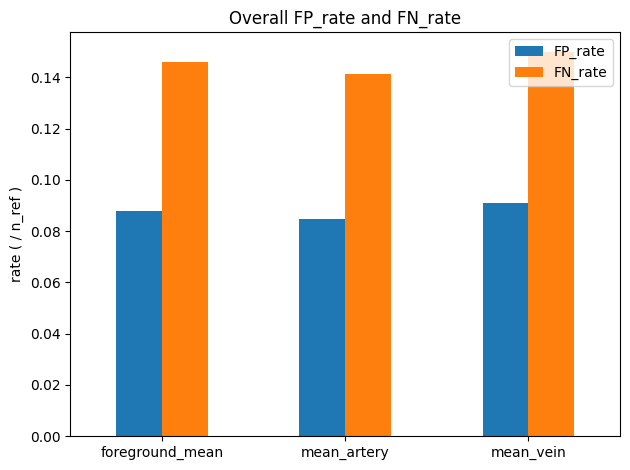

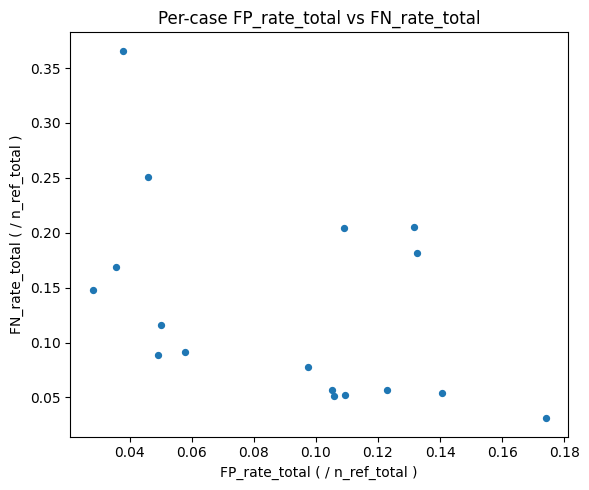

<Figure size 1000x500 with 0 Axes>

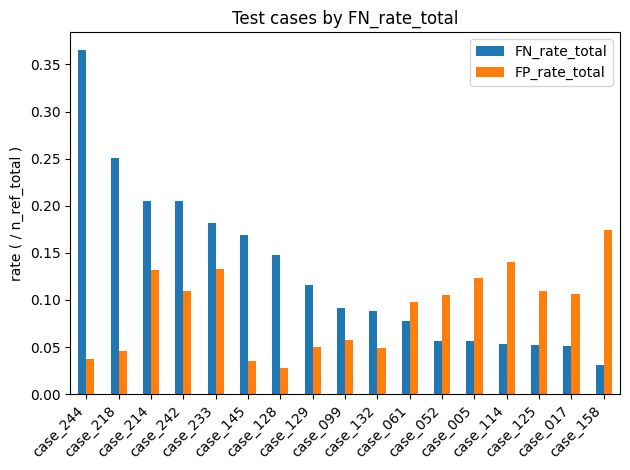

,scope,Dice,IoU,FP,FN,TP,TN,n_pred,n_ref,FP_rate,FN_rate
0,foreground_mean,0.885825,0.798272,37961.382353,62986.176471,368266.382353,8.233745e+07,406227.764706,431252.558824,0.088026,0.146054
1,mean_artery,0.888772,0.802650,33489.823529,55944.823529,339939.352941,8.237729e+07,373429.176471,395884.176471,0.084595,0.141316
2,mean_vein,0.882877,0.793894,42432.941176,70027.529412,396593.411765,8.229761e+07,439026.352941,466620.941176,0.090937,0.150074


,case,FP_artery,FN_artery,n_ref_artery,FP_rate_artery,FN_rate_artery,FP_vein,FN_vein,n_ref_vein,FP_rate_vein,FN_rate_vein,FP_total,FN_total,n_ref_total,FP_rate_total,FN_rate_total
0,case_244,22877,192151,531274,0.043061,0.361680,24310,265079,718667,0.033827,0.368848,47187,457230,1249941,0.037751,0.365801
1,case_218,26995,139966,539085,0.050076,0.259636,33106,188547,770722,0.042955,0.244637,60101,328513,1309807,0.045885,0.250810
2,case_242,56172,102970,575250,0.097648,0.179000,80991,154094,681307,0.118876,0.226174,137163,257064,1256557,0.109158,0.204578
3,case_233,50341,89889,461950,0.108975,0.194586,79504,87647,517777,0.153549,0.169276,129845,177536,979727,0.132532,0.181210
4,case_214,52687,64229,419121,0.125708,0.153247,57860,108172,421374,0.137313,0.256713,110547,172401,840495,0.131526,0.205118
5,case_128,7980,69184,449167,0.017766,0.154027,17428,64525,452797,0.038490,0.142503,25408,133709,901964,0.028170,0.148242
6,case_145,8662,69778,351296,0.024657,0.198630,18592,58795,411875,0.045140,0.142750,27254,128573,763171,0.035712,0.168472
7,case_132,12437,32584,361933,0.034363,0.090028,24060,33154,382216,0.062949,0.086742,36497,65738,744149,0.049045,0.088340
8,case_129,14040,24892,237288,0.059169,0.104902,13662,39220,315727,0.043272,0.124221,27702,64112,553015,0.050093,0.115932
9,case_099,18771,31563,340853,0.055071,0.092600,21032,31638,347382,0.060544,0.091076,39803,63201,688235,0.057833,0.091831


In [4]:
# nnunet + vesselfm
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

METRICS_JSON = Path("/projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/data/nnUNet_results/Dataset003_vesselfm_good/preds/ensemble_seed1-5/metrics.json")
CLASS_NAMES = {"artery": "1", "vein": "2"}

def extract_case_id(pred_path: str) -> str:
    m = re.search(r"(case_\d+)", pred_path or "")
    if m:
        return m.group(1)
    p = Path(pred_path) if pred_path else Path("unknown")
    name = p.name
    if name.endswith(".nii.gz"):
        return name[:-7]
    return p.stem

def extract_fp_fn(metric_dict: dict):
    if not isinstance(metric_dict, dict):
        return (None, None)
    if "False_Positive_and_Negative_Score" in metric_dict:
        v = metric_dict["False_Positive_and_Negative_Score"]
        if isinstance(v, (list, tuple)) and len(v) == 2:
            return (v[0], v[1])
        if isinstance(v, dict):
            fp = v.get("FP", v.get("false_positive", v.get("fp", None)))
            fn = v.get("FN", v.get("false_negative", v.get("fn", None)))
            if fp is not None or fn is not None:
                return (fp, fn)
    return (metric_dict.get("FP", None), metric_dict.get("FN", None))

def safe_rate(num, den):
    if num is None or den is None:
        return None
    try:
        den = float(den)
        if den == 0:
            return None
        return float(num) / den
    except Exception:
        return None

with METRICS_JSON.open("r") as f:
    data = json.load(f)

per_case = data.get("metric_per_case", [])
if not per_case:
    raise ValueError(f"No 'metric_per_case' found in {METRICS_JSON}")

rows = []
for item in per_case:
    pred_file = item.get("prediction_file", "")
    case_id = extract_case_id(pred_file)
    metrics = item.get("metrics", {})
    m_art = metrics.get(CLASS_NAMES["artery"], {})
    m_vein = metrics.get(CLASS_NAMES["vein"], {})

    fp_a, fn_a = extract_fp_fn(m_art)
    fp_v, fn_v = extract_fp_fn(m_vein)

    nref_a = m_art.get("n_ref", None) if isinstance(m_art, dict) else None
    nref_v = m_vein.get("n_ref", None) if isinstance(m_vein, dict) else None

    fp_total = (fp_a + fp_v) if (fp_a is not None and fp_v is not None) else None
    fn_total = (fn_a + fn_v) if (fn_a is not None and fn_v is not None) else None
    nref_total = (nref_a + nref_v) if (nref_a is not None and nref_v is not None) else None

    rows.append({
        "case": case_id,

        "FP_artery": fp_a,
        "FN_artery": fn_a,
        "n_ref_artery": nref_a,
        "FP_rate_artery": safe_rate(fp_a, nref_a),
        "FN_rate_artery": safe_rate(fn_a, nref_a),

        "FP_vein": fp_v,
        "FN_vein": fn_v,
        "n_ref_vein": nref_v,
        "FP_rate_vein": safe_rate(fp_v, nref_v),
        "FN_rate_vein": safe_rate(fn_v, nref_v),

        "FP_total": fp_total,
        "FN_total": fn_total,
        "n_ref_total": nref_total,
        "FP_rate_total": safe_rate(fp_total, nref_total),
        "FN_rate_total": safe_rate(fn_total, nref_total),
    })

df_cases = pd.DataFrame(rows).sort_values(
    by=["FN_total", "FP_total"],
    ascending=[False, False],
    na_position="last"
).reset_index(drop=True)

fg = data.get("foreground_mean", None)
m = data.get("mean", None)
if fg is None or m is None or CLASS_NAMES["artery"] not in m or CLASS_NAMES["vein"] not in m:
    raise ValueError("Missing keys: require top-level 'foreground_mean' and 'mean' with class IDs for artery/vein.")

def pick_stats_with_rate(d: dict):
    out = {
        "Dice": d.get("Dice", None),
        "IoU": d.get("IoU", None),
        "FP": d.get("FP", None),
        "FN": d.get("FN", None),
        "TP": d.get("TP", None),
        "TN": d.get("TN", None),
        "n_pred": d.get("n_pred", None),
        "n_ref": d.get("n_ref", None),
    }
    out["FP_rate"] = safe_rate(out["FP"], out["n_ref"])
    out["FN_rate"] = safe_rate(out["FN"], out["n_ref"])
    return out

df_overall = pd.DataFrame([
    {"scope": "foreground_mean", **pick_stats_with_rate(fg)},
    {"scope": "mean_artery", **pick_stats_with_rate(m[CLASS_NAMES["artery"]])},
    {"scope": "mean_vein", **pick_stats_with_rate(m[CLASS_NAMES["vein"]])},
])

display(df_overall)
display(df_cases)

overall_plot = df_overall.set_index("scope")[["FP_rate", "FN_rate"]].astype(float)

plt.figure(figsize=(8, 4))
overall_plot.plot(kind="bar")
plt.title("Overall FP_rate and FN_rate")
plt.xlabel("")
plt.ylabel("rate ( / n_ref )")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plot_df = df_cases[["case", "FP_rate_total", "FN_rate_total"]].copy()
plot_df["FP_rate_total"] = pd.to_numeric(plot_df["FP_rate_total"], errors="coerce")
plot_df["FN_rate_total"] = pd.to_numeric(plot_df["FN_rate_total"], errors="coerce")
plot_df = plot_df.dropna(subset=["FP_rate_total", "FN_rate_total"])

plt.figure(figsize=(6, 5))
plt.scatter(plot_df["FP_rate_total"], plot_df["FN_rate_total"], s=18)
plt.title("Per-case FP_rate_total vs FN_rate_total")
plt.xlabel("FP_rate_total ( / n_ref_total )")
plt.ylabel("FN_rate_total ( / n_ref_total )")
plt.tight_layout()
plt.show()

TOPK = 20
topk = df_cases[["case", "FP_rate_total", "FN_rate_total"]].copy()
topk["FP_rate_total"] = pd.to_numeric(topk["FP_rate_total"], errors="coerce")
topk["FN_rate_total"] = pd.to_numeric(topk["FN_rate_total"], errors="coerce")
topk = topk.dropna(subset=["FP_rate_total", "FN_rate_total"]).sort_values("FN_rate_total", ascending=False).head(TOPK)

topk_plot = topk.set_index("case")[["FN_rate_total", "FP_rate_total"]]

plt.figure(figsize=(10, 5))
topk_plot.plot(kind="bar")
plt.title(f"Test cases by FN_rate_total")
plt.xlabel("")
plt.ylabel("rate ( / n_ref_total )")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


def extract_case_id(pred_path: str) -> str:
    m = re.search(r"(case_\d+)", pred_path or "")
    if m:
        return m.group(1)
    p = Path(pred_path) if pred_path else Path("unknown")
    name = p.name
    if name.endswith(".nii.gz"):
        return name[:-7]
    return p.stem

def extract_fp_fn(metric_dict: dict):
    if not isinstance(metric_dict, dict):
        return (None, None)
    if "False_Positive_and_Negative_Score" in metric_dict:
        v = metric_dict["False_Positive_and_Negative_Score"]
        if isinstance(v, (list, tuple)) and len(v) == 2:
            return (v[0], v[1])
        if isinstance(v, dict):
            fp = v.get("FP", v.get("false_positive", v.get("fp", None)))
            fn = v.get("FN", v.get("false_negative", v.get("fn", None)))
            if fp is not None or fn is not None:
                return (fp, fn)
    return (metric_dict.get("FP", None), metric_dict.get("FN", None))

def safe_rate(num, den):
    if num is None or den is None:
        return None
    try:
        den = float(den)
        if den == 0:
            return None
        return float(num) / den
    except Exception:
        return None

with METRICS_JSON.open("r") as f:
    data = json.load(f)

per_case = data.get("metric_per_case", [])
if not per_case:
    raise ValueError(f"No 'metric_per_case' found in {METRICS_JSON}")

rows = []
for item in per_case:
    pred_file = item.get("prediction_file", "")
    case_id = extract_case_id(pred_file)
    metrics = item.get("metrics", {})
    m_art = metrics.get(CLASS_NAMES["artery"], {})
    m_vein = metrics.get(CLASS_NAMES["vein"], {})

    fp_a, fn_a = extract_fp_fn(m_art)
    fp_v, fn_v = extract_fp_fn(m_vein)

    nref_a = m_art.get("n_ref", None) if isinstance(m_art, dict) else None
    nref_v = m_vein.get("n_ref", None) if isinstance(m_vein, dict) else None

    fp_total = (fp_a + fp_v) if (fp_a is not None and fp_v is not None) else None
    fn_total = (fn_a + fn_v) if (fn_a is not None and fn_v is not None) else None
    nref_total = (nref_a + nref_v) if (nref_a is not None and nref_v is not None) else None

    rows.append({
        "case": case_id,

        "FP_artery": fp_a,
        "FN_artery": fn_a,
        "n_ref_artery": nref_a,
        "FP_rate_artery": safe_rate(fp_a, nref_a),
        "FN_rate_artery": safe_rate(fn_a, nref_a),

        "FP_vein": fp_v,
        "FN_vein": fn_v,
        "n_ref_vein": nref_v,
        "FP_rate_vein": safe_rate(fp_v, nref_v),
        "FN_rate_vein": safe_rate(fn_v, nref_v),

        "FP_total": fp_total,
        "FN_total": fn_total,
        "n_ref_total": nref_total,
        "FP_rate_total": safe_rate(fp_total, nref_total),
        "FN_rate_total": safe_rate(fn_total, nref_total),
    })

df_cases = pd.DataFrame(rows).sort_values(
    by=["FN_total", "FP_total"],
    ascending=[False, False],
    na_position="last"
).reset_index(drop=True)

fg = data.get("foreground_mean", None)
m = data.get("mean", None)
if fg is None or m is None or CLASS_NAMES["artery"] not in m or CLASS_NAMES["vein"] not in m:
    raise ValueError("Missing keys: require top-level 'foreground_mean' and 'mean' with class IDs for artery/vein.")

def pick_stats_with_rate(d: dict):
    out = {
        "Dice": d.get("Dice", None),
        "IoU": d.get("IoU", None),
        "FP": d.get("FP", None),
        "FN": d.get("FN", None),
        "TP": d.get("TP", None),
        "TN": d.get("TN", None),
        "n_pred": d.get("n_pred", None),
        "n_ref": d.get("n_ref", None),
    }
    out["FP_rate"] = safe_rate(out["FP"], out["n_ref"])
    out["FN_rate"] = safe_rate(out["FN"], out["n_ref"])
    return out

df_overall = pd.DataFrame([
    {"scope": "foreground_mean", **pick_stats_with_rate(fg)},
    {"scope": "mean_artery", **pick_stats_with_rate(m[CLASS_NAMES["artery"]])},
    {"scope": "mean_vein", **pick_stats_with_rate(m[CLASS_NAMES["vein"]])},
])

display(df_overall)
display(df_cases)
